# Part 5: Trend Analysis and Insight Generation

**Objective:** Analyze the structured outputs generated by the LLM to identify patterns, trends, and key insights from airline customer feedback.

**Description:** In this final stage, the structured information produced by the LLM is analyzed to uncover patterns in customer complaints and emerging trends. The enriched dataset, which now includes fields such as complaint topics, severity levets, root causes, and trend signals, is used to perform exploratory analysis. 

A series of visualizations are generated to explore relationships between different variables, such as complaint topics, severity levels, and detected trend signals. These visual analyses help highlight recurring customer issues and potential emerging problems discussed by users. 

The results of this analysis provide actionable insights that can support data-driven business decisions, such as identifying critical service issues, monitoring customer sentiment, and detecting early signals of operational problems. 

In [8]:
# import libraries
import pandas as pd
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [2]:
# read parquet
data = pd.read_parquet("tweets_enriched.parquet")
data.head(5)

# rename the LLM output
data = data.rename(columns={"0": "llm_output"})

In [3]:
# explore the formats and the output
n_cluster = sorted(data["cluster"].unique())

for c in n_cluster: 
    print(c)
    print(data["llm_output"][data["cluster"] == c].value_counts())

-1
llm_output
```json\n{\n  "cluster_label": "change fees",\n  "complaint_topic": "fees",\n  "summary": "customers struggle with reservation change fees",\n  "customer_issue": "change fees unclear",\n  "likely_root_cause": "policy and process confusion",\n  "severity": "medium",\n  "is_complaint": true,\n  "trend_signal": "medium"\n}\n```    16
Name: count, dtype: int64
0
llm_output
```json\n{\n  "cluster_label": "jetblue service",\n  "complaint_topic": "service",\n  "summary": "issues with pilot absence and dirty planes",\n  "customer_issue": "pilot missing, dirty plane",\n  "likely_root_cause": "staffing and cleanliness problems",\n  "severity": "medium",\n  "is_complaint": true,\n  "trend_signal": "medium"\n}\n```    2202
Name: count, dtype: int64
1
llm_output
```json\n{\n  "cluster_label": "inflight entertainment",\n  "complaint_topic": "service",\n  "summary": "complaints about annoying inflight commercials",\n  "customer_issue": "annoying inflight commercials",\n  "likely_root_ca

In [4]:
# clean your json column 
data["llm_output"] = (data["llm_output"]
                      .str.replace("```json", "", regex=False)
                      .str.replace("```", "", regex=False)
                      .str.strip()
                    )
data["llm_output"][0]

'{\n  "cluster_label": "inflight entertainment",\n  "complaint_topic": "service",\n  "summary": "complaints about annoying inflight commercials",\n  "customer_issue": "annoying inflight commercials",\n  "likely_root_cause": "forced entertainment ads",\n  "severity": "medium",\n  "is_complaint": true,\n  "trend_signal": "medium"\n}'

In [5]:
# add your json into columns for the dataset. 
data["llm_output"] = data["llm_output"].apply(json.loads) # convert string JSON to dictionary
data_expanded = pd.concat(
    [
        data.drop(columns=["llm_output"]),
        pd.json_normalize(data["llm_output"]) # Turn the dictionary column into columns
    ],
    axis = 1
)

In [55]:
# see how is complaint topic distribution among locations
location_columns = ['location_atlanta', 'location_austin',
       'location_boston', 'location_brooklyn', 'location_california',
       'location_chicago', 'location_columbus', 'location_ct',
       'location_dallas', 'location_denver', 'location_houston',
       'location_las vegas', 'location_london', 'location_los angeles',
       'location_miami', 'location_nashville', 'location_new york',
       'location_new york city', 'location_ny', 'location_nyc',
       'location_other', 'location_philadelphia', 'location_portland',
       'location_san diego', 'location_san francisco', 'location_seattle',
       'location_texas', 'location_toronto', 'location_usa',
       'location_washington', 'location_washington dc']

data_expanded["location"] = (
    data_expanded[location_columns]
    .idxmax(axis=1)
    .str.replace("location_","", regex=False)
)

data.head(5)

pivot_location = data_expanded.pivot_table(
    index = "location",
    columns = "complaint_topic",
    aggfunc = "size",
    fill_value = 0
)
top_10 = pivot_location.iloc[:10]
top_10

complaint_topic,delay,fees,none,service
location,,,,
atlanta,26,0,0,5
austin,37,0,0,39
boston,46,0,3,147
brooklyn,17,0,0,59
california,18,0,0,11
chicago,76,0,0,51
columbus,24,0,0,6
ct,18,0,0,14
dallas,25,0,0,64


### Let's get into our analysis: 

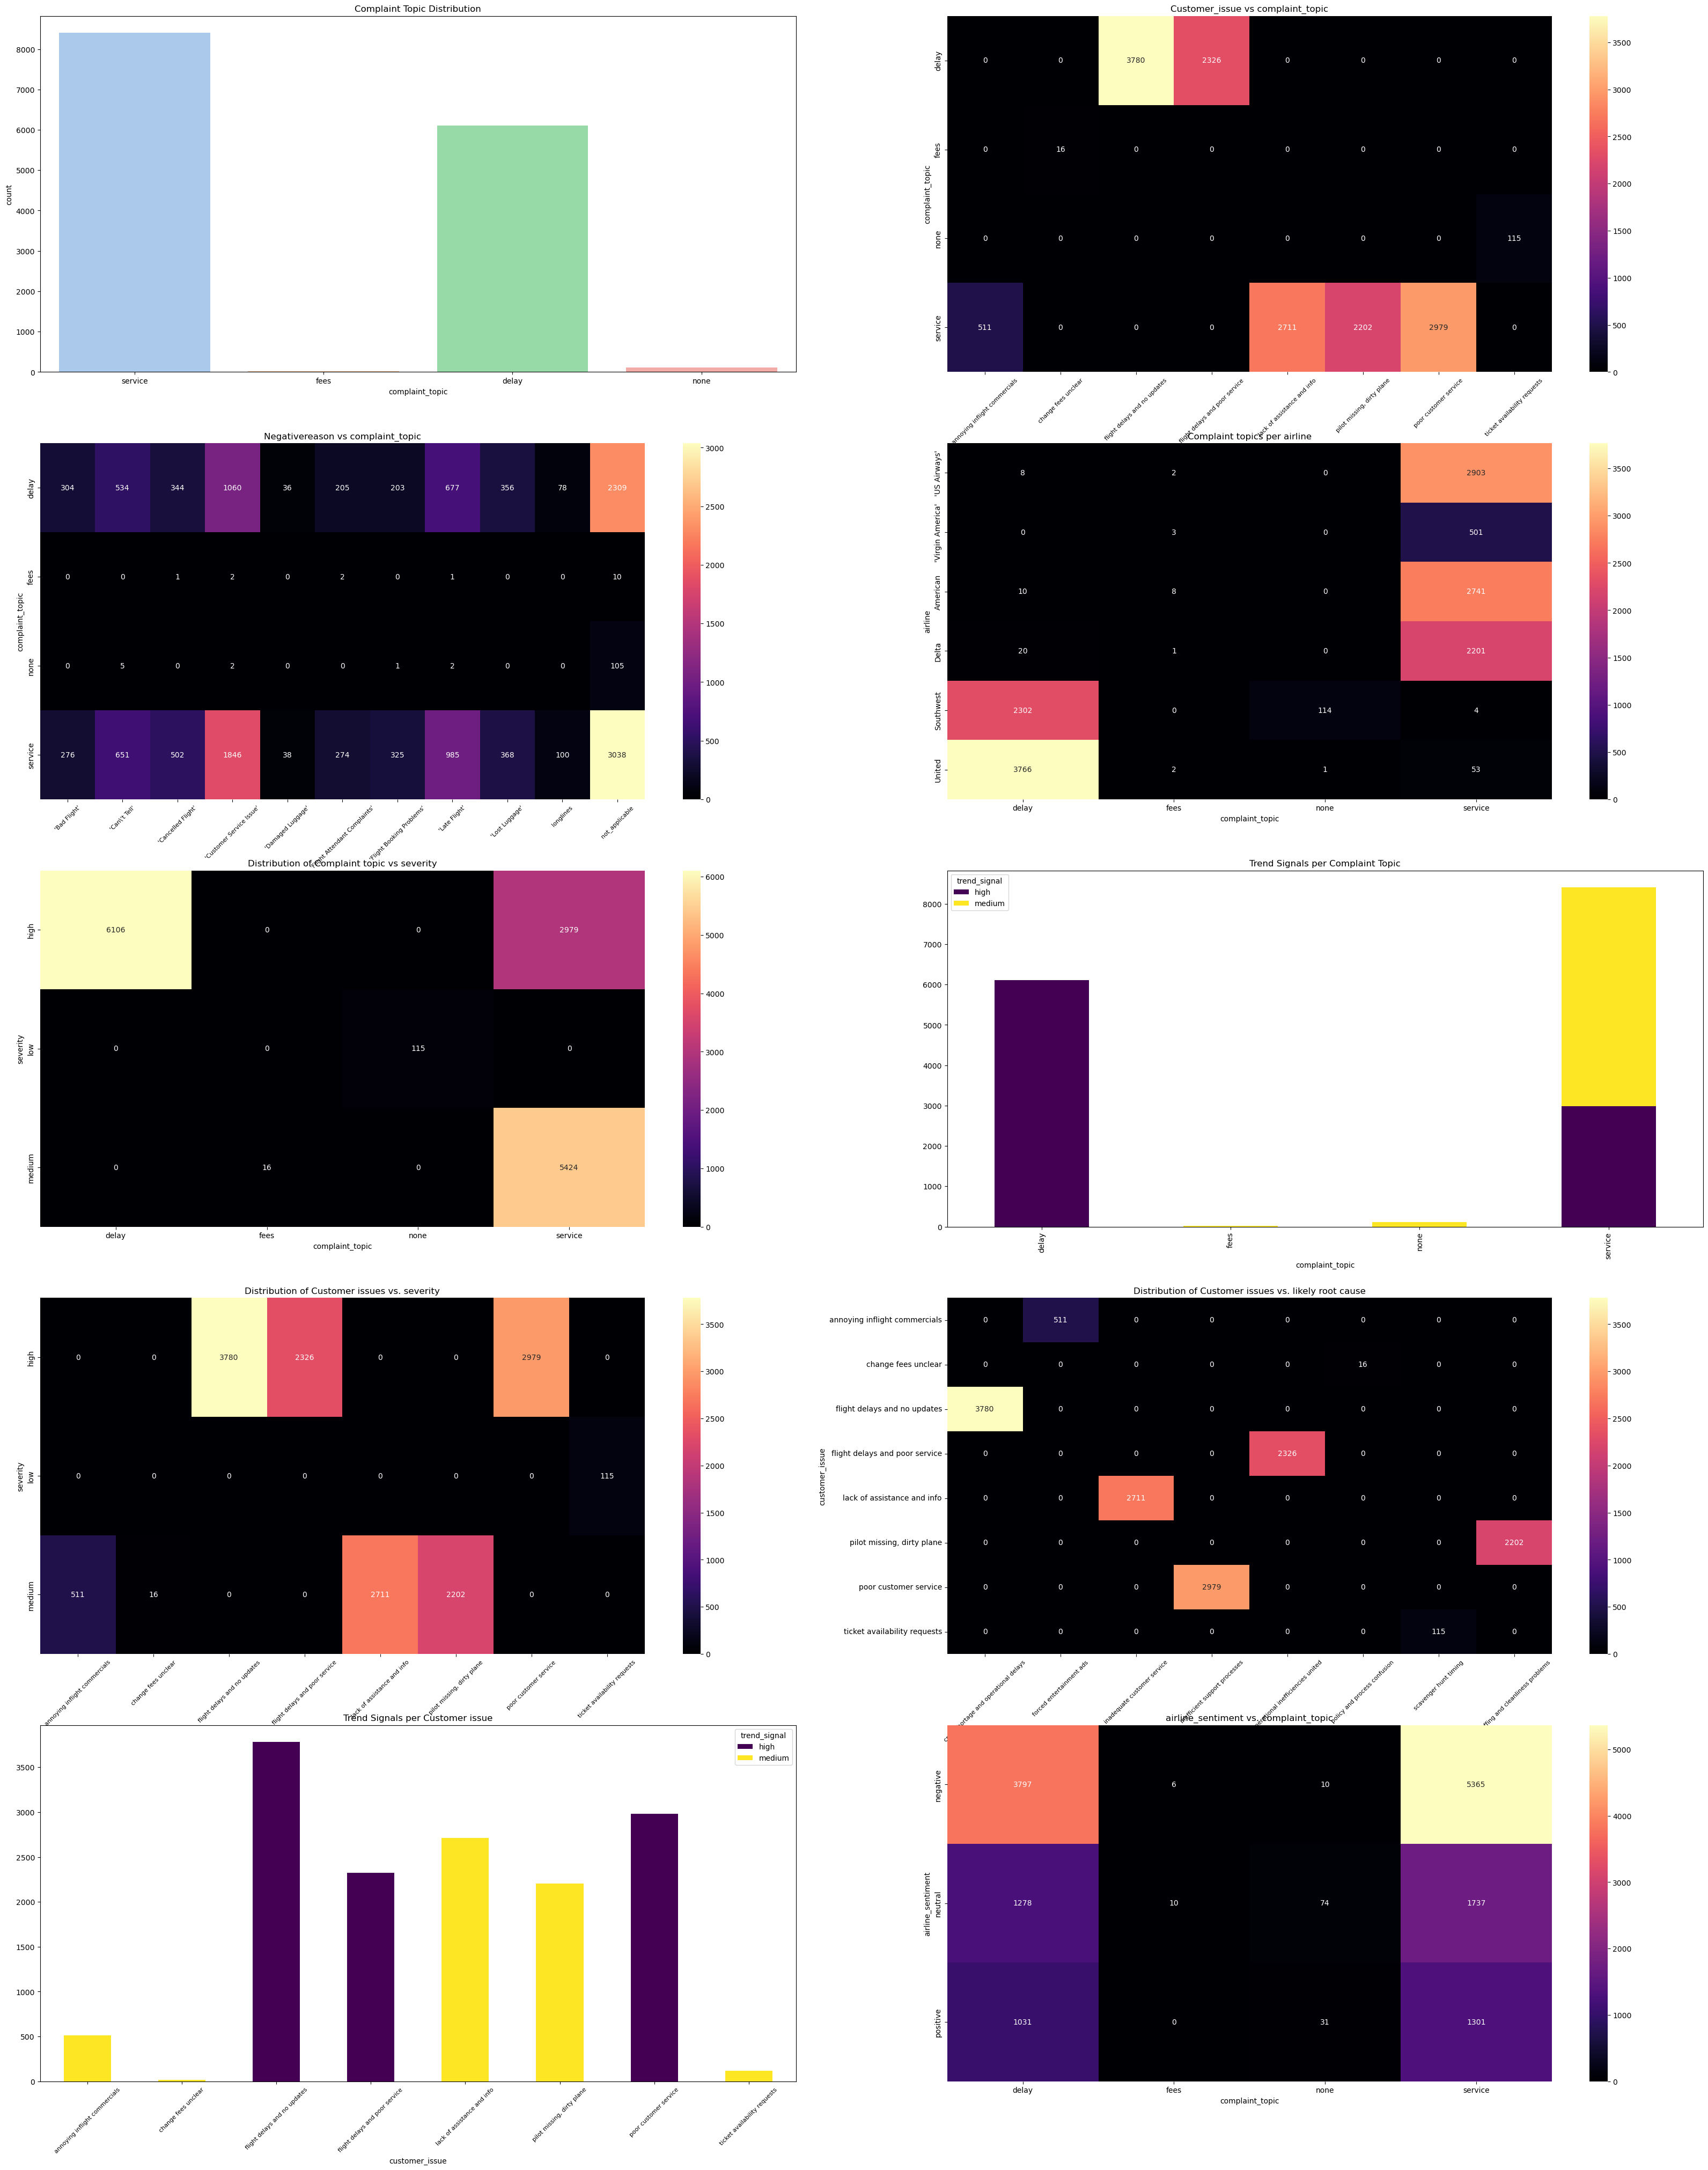

<Figure size 1000x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

In [65]:
# Let's create a figure with 12 subplots
n_cols = 2
n_rows = math.ceil(10/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(40,10*n_rows))
axes = axes.flatten()

#--------------------------------------------------------------
# Complaint_topics Distribution
sns.countplot(
    data = data_expanded,
    x = "complaint_topic",
    hue="complaint_topic",
    palette="pastel",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Complaint Topic Distribution")
#------------------------------------------------------------
# Issues within complaint_topic 
pivot = pd.crosstab(data_expanded["complaint_topic"], data_expanded["customer_issue"])

sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="magma", 
    ax=axes[1]
)

axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].set_title("Customer_issue vs complaint_topic")
#------------------------------------------------------------
# negativereason vs. complaint_topic 
pivot = pd.crosstab(data_expanded["complaint_topic"], data_expanded["negativereason"])

sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="magma", 
    ax=axes[2]
)

axes[2].tick_params(axis="x", rotation=45, labelsize=8)
axes[2].set_title("Negativereason vs complaint_topic")
#------------------------------------------------------------
# complaint_topics per airline
pivot = pd.crosstab(data_expanded["airline"], data_expanded["complaint_topic"])

plt.figure(figsize=(10,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="magma", 
    ax=axes[3]
)

axes[3].set_title("Complaint topics per airline")
#------------------------------------------------------------
# Severity vs complaint_topic
pivot = pd.crosstab(data_expanded["severity"], data_expanded["complaint_topic"])

plt.figure(figsize=(15,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="magma",
    ax=axes[4]
)

axes[4].set_title("Distribution of Complaint topic vs severity")
#------------------------------------------------------------
# Complaint_topic vs trend_signal
pivot = data_expanded.pivot_table(
    index="complaint_topic",
    columns="trend_signal",
    aggfunc="size",
    fill_value=0
)

pivot.plot(
    kind="bar",
    stacked=True,
    colormap="viridis", 
    ax = axes[5]
)

axes[5].set_title("Trend Signals per Complaint Topic")
#------------------------------------------------------------
# customer issues vs severity
pivot = pd.crosstab(data_expanded["severity"], data_expanded["customer_issue"])

plt.figure(figsize=(15,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="magma", 
    ax=axes[6]
)

axes[6].tick_params(axis="x", rotation=45, labelsize=8)
axes[6].set_title("Distribution of Customer issues vs. severity")
#------------------------------------------------------------
# customer_issue vs. likely root cause.
pivot = pd.crosstab(data_expanded["customer_issue"], data_expanded["likely_root_cause"])

plt.figure(figsize=(15,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="magma", 
    ax=axes[7]
)

axes[7].tick_params(axis="x", rotation=45, labelsize=8)
axes[7].set_title("Distribution of Customer issues vs. likely root cause")
#------------------------------------------------------------
# trend_signal vs customer issue
pivot = data_expanded.pivot_table(
    index="customer_issue",
    columns="trend_signal",
    aggfunc="size",
    fill_value=0
)

pivot.plot(
    kind="bar",
    stacked=True,
    colormap="viridis", 
    ax = axes[8]
)

axes[8].tick_params(axis="x", rotation=45, labelsize=8)
axes[8].set_title("Trend Signals per Customer issue")
#------------------------------------------------------------
# airline_sentiment vs. complaint_topic
pivot = pd.crosstab(data_expanded["airline_sentiment"], data_expanded["complaint_topic"])

plt.figure(figsize=(15,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="magma", 
    ax=axes[9]
)
axes[9].set_title("airline_sentiment vs. complaint_topic")

plt.tight_layout()
plt.show()

As we can see, the LLM enhanced the metrics that can be analyzed for different trends and patterns that just by seeing the data couldn't have been obtained. This type of trending can drive decision making and also commercial and budget strategy if read properly. 